# Extract science periods from raw drifter GPS data

Filter raw Baltic drifter trajectories to isolate the science (free-drifting) periods by removing pre-deployment, beaching, and post-beaching phases.

In [1]:
raw_csv = "data/drifters_raw.csv"
out_csv = "data/drifters_science.csv"

# Baltic bounding box
lat_min, lat_max = 53.5, 56.0
lon_min, lon_max = 9.0, 13.0

# Minimum records per drifter
min_records = 100

# Deployment location
deploy_lat, deploy_lon = 54.33, 10.15

# Thresholds
deployment_radius_m = 2000.0
speed_quantile = 0.99  # flag speeds above this quantile as non-science


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.io.img_tiles as cimgt
from pathlib import Path


## Load and basic filter

In [3]:
df = pd.read_csv(raw_csv, parse_dates=["date_UTC"], dayfirst=True)
df["D_number"] = "D" + df["D_number"].astype(str)
df = df.sort_values(["D_number", "date_UTC"]).reset_index(drop=True)

# Filter to Baltic bounding box
df = df[
    (df["Latitude"] >= lat_min) & (df["Latitude"] <= lat_max)
    & (df["Longitude"] >= lon_min) & (df["Longitude"] <= lon_max)
].copy()

# Deduplicate
df = df.drop_duplicates(subset=["D_number", "date_UTC"]).reset_index(drop=True)

# Drop drifters with too few records
counts = df["D_number"].value_counts()
keep = counts[counts >= min_records].index
df = df[df["D_number"].isin(keep)].reset_index(drop=True)

print(f"Drifters kept: {sorted(df['D_number'].unique())}")
print(f"Total records: {len(df)}")
print(df.groupby("D_number").size())

Drifters kept: ['D298', 'D299', 'D300', 'D301', 'D302', 'D303']
Total records: 12496
D_number
D298    2120
D299    2425
D300    2032
D301    1160
D302    2323
D303    2436
dtype: int64


## Resample to 1-minute resolution

In [4]:
m_per_deg = 111120.0

resampled = []
for did, g in df.groupby("D_number"):
    g = g.set_index("date_UTC")[["Latitude", "Longitude"]]
    g = g.resample("1min").mean()  # puts NaN where no data
    g = g.interpolate("time")      # linear in time
    g = g.dropna()
    g["D_number"] = did
    resampled.append(g)

df = pd.concat(resampled).reset_index()
df = df.sort_values(["D_number", "date_UTC"]).reset_index(drop=True)

# Derive speed and acceleration from interpolated positions
records = []
for _, g in df.groupby("D_number"):
    g = g.copy()
    dt = g["date_UTC"].diff().dt.total_seconds()
    dlat = g["Latitude"].diff() * m_per_deg
    dlon = g["Longitude"].diff() * m_per_deg * np.cos(np.radians(g["Latitude"]))
    g["speed_mps"] = np.sqrt(dlat**2 + dlon**2) / dt
    g["speed_smooth"] = g["speed_mps"].rolling(15, center=True, min_periods=1).mean()
    g["accel_mps2"] = g["speed_smooth"].diff() / dt
    # Rolling 15-min max for thresholding
    g["accel_max15"] = g["accel_mps2"].abs().rolling(15, center=True, min_periods=1).max()
    g["speed_max15"] = g["speed_mps"].rolling(15, center=True, min_periods=1).max()
    records.append(g)

df = pd.concat(records).reset_index(drop=True)

print(f"{len(df)} records at 1-min resolution")
for did in sorted(df["D_number"].unique()):
    g = df[df["D_number"] == did]
    print(f"  {did}: {len(g)} pts, {g['date_UTC'].min()} to {g['date_UTC'].max()}")


139973 records at 1-min resolution
  D298: 21983 pts, 2023-04-20 10:04:00 to 2023-05-05 16:26:00
  D299: 23413 pts, 2023-04-20 10:09:00 to 2023-05-06 16:21:00
  D300: 21825 pts, 2023-04-20 10:07:00 to 2023-05-05 13:51:00
  D301: 21414 pts, 2023-04-20 10:05:00 to 2023-05-05 06:58:00
  D302: 23746 pts, 2023-04-20 10:07:00 to 2023-05-06 21:52:00
  D303: 27592 pts, 2023-04-20 10:05:00 to 2023-05-09 13:56:00


## Classify science periods

In [5]:
accel_threshold = 0.002  # m/s², max over 15-min window
speed_threshold = 2.0    # m/s, max over 15-min window

# Non-science: rolling-max accel or speed exceeds threshold
df["is_science"] = (
    (df["accel_max15"] <= accel_threshold)
    & (df["speed_max15"] <= speed_threshold)
)

# Also remove pre-deployment (near dock at start)
for did, g in df.groupby("D_number"):
    dlat = (g["Latitude"].values - deploy_lat) * m_per_deg
    dlon = (g["Longitude"].values - deploy_lon) * m_per_deg * np.cos(np.radians(deploy_lat))
    dist = np.sqrt(dlat**2 + dlon**2)
    for i, idx in enumerate(g.index):
        if dist[i] > deployment_radius_m:
            break
        df.loc[idx, "is_science"] = False

print(f"Science: {df['is_science'].sum()} / {len(df)} records")
print()
for did in sorted(df["D_number"].unique()):
    g = df[df["D_number"] == did]
    ns = g["is_science"].sum()
    t0 = g.loc[g["is_science"], "date_UTC"].min()
    t1 = g.loc[g["is_science"], "date_UTC"].max()
    print(f"  {did}: {ns} / {len(g)} science, {t0} to {t1}")


Science: 104763 / 139973 records

  D298: 16334 / 21983 science, 2023-04-24 07:24:00 to 2023-05-05 16:26:00
  D299: 17546 / 23413 science, 2023-04-24 07:24:00 to 2023-05-06 15:52:00
  D300: 16229 / 21825 science, 2023-04-24 07:23:00 to 2023-05-05 13:51:00
  D301: 14993 / 21414 science, 2023-04-24 07:24:00 to 2023-05-05 06:34:00
  D302: 17916 / 23746 science, 2023-04-24 07:25:00 to 2023-05-06 21:52:00
  D303: 21745 / 27592 science, 2023-04-24 07:26:00 to 2023-05-09 13:56:00


## All drifter trajectories

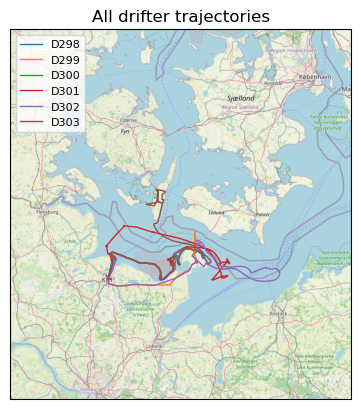

In [6]:
tiles = cimgt.OSM()
geo = ccrs.Geodetic()

drifter_ids = sorted(df["D_number"].unique())
colors = {did: f"C{i}" for i, did in enumerate(drifter_ids)}

fig, ax = plt.subplots(subplot_kw=dict(projection=tiles.crs))
ax.set_extent([lon_min, lon_max, lat_min, lat_max], crs=geo)
ax.add_image(tiles, 8)

for did in drifter_ids:
    g = df[df["D_number"] == did]
    ax.plot(g["Longitude"].values, g["Latitude"].values,
            transform=geo, label=did, color=colors[did], linewidth=1)

ax.legend(loc="upper left", fontsize=8)
ax.set_title("All drifter trajectories")
plt.show()


## Science periods only

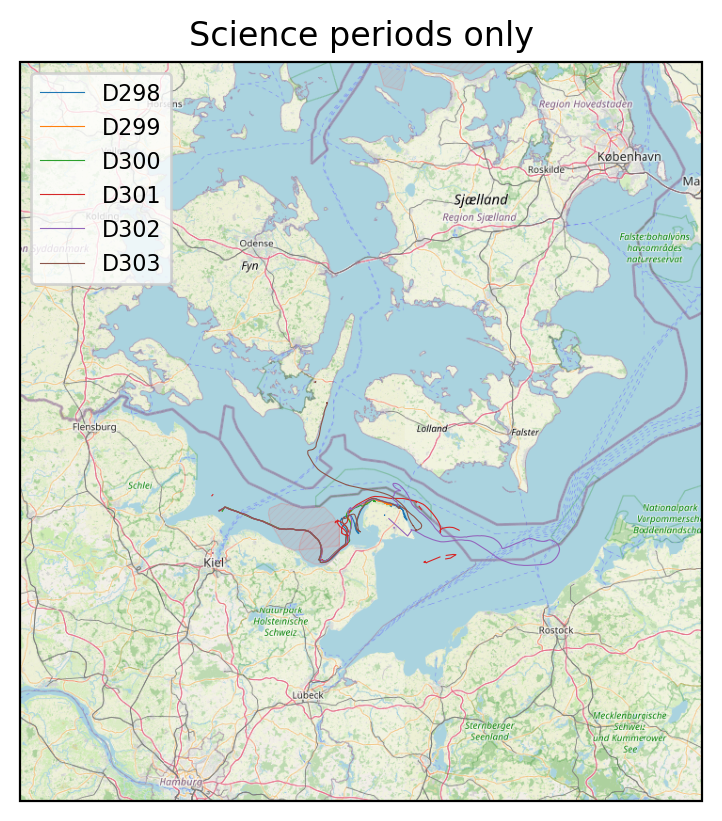

In [7]:
fig, ax = plt.subplots(subplot_kw=dict(projection=tiles.crs), dpi=200)
ax.set_extent([lon_min, lon_max, lat_min, lat_max], crs=geo)
ax.add_image(tiles, 8)

for did in drifter_ids:
    g = df.loc[df["D_number"] == did].copy()
    lon = g["Longitude"].values.astype(float)
    lat = g["Latitude"].values.astype(float)
    lon[~g["is_science"].values] = np.nan
    lat[~g["is_science"].values] = np.nan
    ax.plot(lon, lat, transform=geo, label=did, color=colors[did], linewidth=.4)

ax.legend(loc="upper left", fontsize=8)
ax.set_title("Science periods only")
plt.show()


## Save output

In [8]:
out_path = Path(out_csv)
out_path.parent.mkdir(parents=True, exist_ok=True)
df_science = df.loc[df["is_science"], ["D_number", "date_UTC", "Latitude", "Longitude"]]
df_science.to_csv(out_path, index=False)
print(f"Saved {len(df_science)} science records to {out_path}")


Saved 104763 science records to data/drifters_science.csv
